
指定 zoneid = 1 的受力计算结果:

粘性力矢量:
  Fx (粘性力) = 2.471011e-01
  Fy (粘性力) = -2.200967e-06
  粘性力大小 = 2.471011e-01

压力矢量:
  Fx (压力) = 3.931186e-02
  Fy (压力) = -4.204700e-03
  压力大小 = 3.953609e-02

总受力矢量:
  Fx (总力) = 2.864130e-01
  Fy (总力) = -4.206901e-03
  总受力大小 = 2.864439e-01



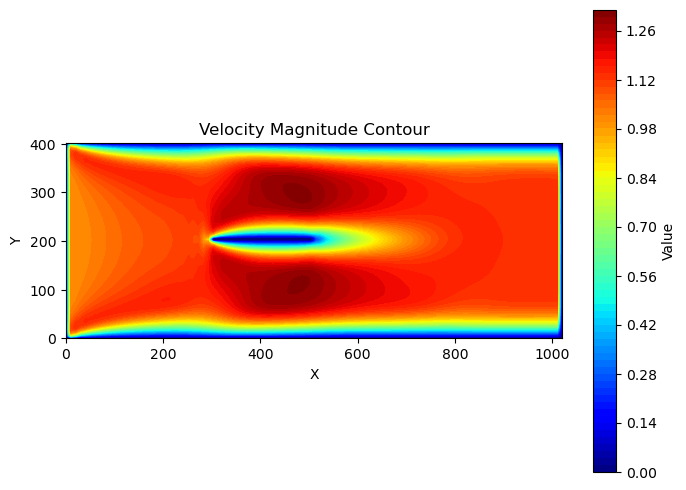

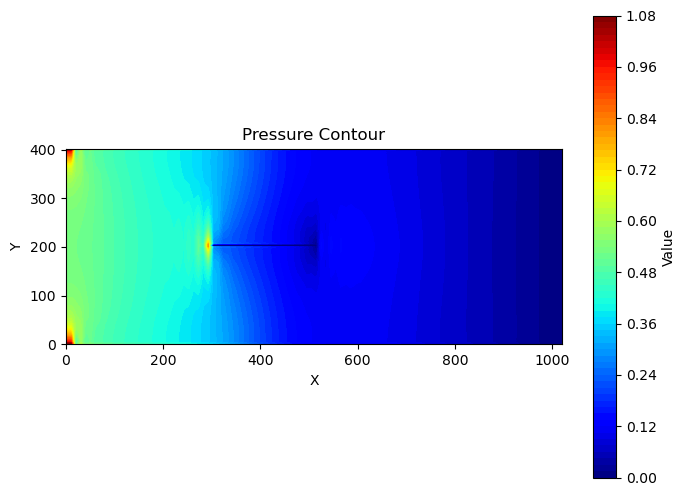

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def plot_contour(data, x, y, title, cmap='coolwarm'):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111)
    
    cs = ax.contourf(x, y, data, levels=80, cmap=cmap)
    fig.colorbar(cs, ax=ax, label='Value')
    
    ax.set_title(title)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    plt.gca().set_aspect('equal', adjustable='box')
    plt.show()

def plot_contour2(data, x, y, title, cmap='coolwarm', vmin=None, vmax=None):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111)
    
    cs = ax.contourf(x, y, data, levels=80, cmap=cmap, vmin=vmin, vmax=vmax)
    fig.colorbar(cs, ax=ax, label='Value')
    
    ax.set_title(title)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    plt.gca().set_aspect('equal', adjustable='box')
    plt.show()

def load_and_combine_data(i):
    u_data = []
    v_data = []
    p_data = []
    
    for idx in range(i + 1):
        u = np.loadtxt(f'u_{idx}.dat', dtype=np.float64)
        v = np.loadtxt(f'v_{idx}.dat', dtype=np.float64)
        p = np.loadtxt(f'p_{idx}.dat', dtype=np.float64)
        
        if idx == 0:
            u_trimmed = u[:, :-2]
            v_trimmed = v[:, :-2]
            p_trimmed = p[:, :-2]
        elif idx == i:
            u_trimmed = u[:, 2:]
            v_trimmed = v[:, 2:]
            p_trimmed = p[:, 2:]
        else:
            u_trimmed = u[:, 2:-2]
            v_trimmed = v[:, 2:-2]
            p_trimmed = p[:, 2:-2]
            
        u_data.append(u_trimmed)
        v_data.append(v_trimmed)
        p_data.append(p_trimmed)
    
    return (np.concatenate(u_data, axis=1),
            np.concatenate(v_data, axis=1),
            np.concatenate(p_data, axis=1))

def calculate_forces(zoneid_matrix, u_result, v_result, p_result, target_zoneid, dx, dy, mu):
    """
    计算指定zoneid的受力
    
    参数:
    - zoneid_matrix: zoneid矩阵
    - u_result, v_result, p_result: 速度和压力场
    - target_zoneid: 目标zoneid
    - dx, dy: 网格间距
    - mu: 动力粘度
    
    返回:
    - viscous_force: 粘性力矢量 [Fx, Fy]
    - pressure_force: 压力矢量 [Fx, Fy]
    - total_force: 总受力矢量 [Fx, Fy]
    """
    ny, nx = zoneid_matrix.shape
    
    # 初始化受力
    viscous_force = np.array([0.0, 0.0])
    pressure_force = np.array([0.0, 0.0])
    
    # 遍历所有网格点
    for j in range(ny):
        for i in range(nx):
            # 如果当前点是目标zoneid
            if zoneid_matrix[j, i] == target_zoneid:
                # 检查上方单元 (j-1)
                if j > 0 and zoneid_matrix[j-1, i] == 0:
                    # 压力 (向下为负)
                    p_force = -p_result[j-1, i] * dx
                    pressure_force[1] += p_force
                    
                    # 粘性力
                    du_dy = u_result[j-1, i] / ( dy)
                    visc_force = dx * mu * du_dy
                    viscous_force[0] += visc_force
                
                # 检查下方单元 (j+1)
                if j < ny-1 and zoneid_matrix[j+1, i] == 0:
                    # 压力 (向上为正)
                    p_force = p_result[j+1, i] * dx
                    pressure_force[1] += p_force
                    
                    # 粘性力
                    du_dy = u_result[j+1, i] / ( dy)
                    visc_force = dx * mu * du_dy
                    viscous_force[0] += visc_force
                
                # 检查左侧单元 (i-1)
                if i > 0 and zoneid_matrix[j, i-1] == 0:
                    # 压力 (向右为正)
                    p_force = p_result[j, i-1] * dy
                    pressure_force[0] += p_force
                    
                    # 粘性力
                    dv_dx = v_result[j, i-1] / ( dx)
                    visc_force = dy * mu * dv_dx
                    viscous_force[1] += visc_force
                
                # 检查右侧单元 (i+1)
                if i < nx-1 and zoneid_matrix[j, i+1] == 0:
                    # 压力 (向左为负)
                    p_force = -p_result[j, i+1] * dy
                    pressure_force[0] += p_force
                    
                    # 粘性力
                    dv_dx = -v_result[j, i+1] / ( dx)
                    visc_force = dy * mu * dv_dx
                    viscous_force[1] += visc_force
    
    total_force = viscous_force + pressure_force
    
    return viscous_force, pressure_force, total_force

# 主程序
if __name__ == "__main__":
    i = int(input("请输入 i 的值（例如 2）: "))
    aspect_ratio = float(input("请输入 x/y 的比例（例如 5.0）: "))
    
    # 输入目标zoneid
    zoneid_input = input("请输入指定zoneid（不输入直接回车默认为1）: ")
    target_zoneid = 1 if zoneid_input.strip() == "" else int(zoneid_input)
    
    if target_zoneid == 0:
        print("错误: zoneid不可为0!")
        exit()
    
    # 输入网格参数
    dx = float(input("请输入网格dx: "))
    dy = float(input("请输入网格dy: "))
    mu = float(input("请输入动力粘度μ: "))
    
    # 加载数据
    u_result, v_result, p_result = load_and_combine_data(i)
    
    # 加载zoneid矩阵
    zoneid_matrix = np.loadtxt('zoneid.dat', dtype=np.int32)
    
    # 检查矩阵尺寸是否一致
    if zoneid_matrix.shape != u_result.shape:
        print(f"警告: zoneid矩阵尺寸 {zoneid_matrix.shape} 与速度场尺寸 {u_result.shape} 不一致!")
    
    # 计算受力
    viscous_force, pressure_force, total_force = calculate_forces(
        zoneid_matrix, u_result, v_result, p_result, 
        target_zoneid, dx, dy, mu
    )
    
    # 打印结果
    print("\n" + "="*60)
    print(f"指定 zoneid = {target_zoneid} 的受力计算结果:")
    print("="*60)
    print(f"\n粘性力矢量:")
    print(f"  Fx (粘性力) = {viscous_force[0]:.6e}")
    print(f"  Fy (粘性力) = {viscous_force[1]:.6e}")
    print(f"  粘性力大小 = {np.linalg.norm(viscous_force):.6e}")
    
    print(f"\n压力矢量:")
    print(f"  Fx (压力) = {pressure_force[0]:.6e}")
    print(f"  Fy (压力) = {pressure_force[1]:.6e}")
    print(f"  压力大小 = {np.linalg.norm(pressure_force):.6e}")
    
    print(f"\n总受力矢量:")
    print(f"  Fx (总力) = {total_force[0]:.6e}")
    print(f"  Fy (总力) = {total_force[1]:.6e}")
    print(f"  总受力大小 = {np.linalg.norm(total_force):.6e}")
    print("="*60 + "\n")
    
    # 保存结果
    np.savetxt('u_combined.dat', u_result)
    np.savetxt('v_combined.dat', v_result)
    np.savetxt('p_combined.dat', p_result)
    
    # 计算速度大小
    velocity_magnitude = np.sqrt(u_result**2 + v_result**2)
    
    # 网格坐标
    ny, nx = velocity_magnitude.shape
    x = np.linspace(0, nx, nx) * aspect_ratio
    y = np.linspace(0, ny, ny)
    y = y[::-1]
    
    X, Y = np.meshgrid(x, y)
    
    # 绘图
    plot_contour(velocity_magnitude, X, Y, 'Velocity Magnitude Contour', cmap='jet')
    plot_contour(p_result, X, Y, 'Pressure Contour', cmap='jet')